In [1]:
import sys
import statsmodels as ss
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt
import os
import seaborn as sns
os.chdir(r"C:\Users\jrdiy\OneDrive\Рабочий стол\vs_code\Time-series\Timer_series_Decomposition\data")
from colorsetup import colors, palette
sns.set_palette(palette)


In [2]:
time = np.arange(1,51)


In [3]:
trend = time * 2.75


Text(0, 0.5, 'electricity')

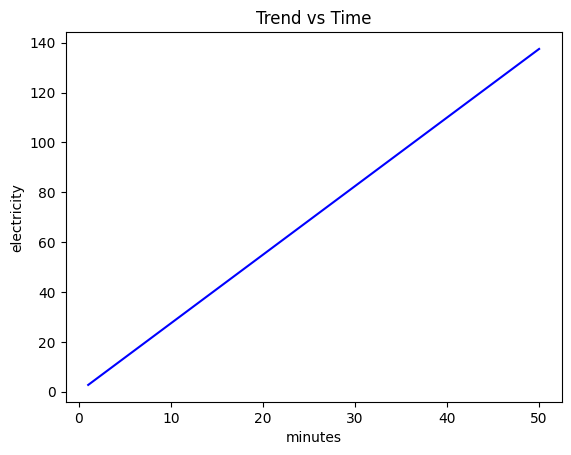

In [4]:
plt.plot(time,trend, 'b')
plt.title("Trend vs Time")
plt.xlabel("minutes")

plt.ylabel("electricity")

In [5]:
seasonal = 10 + np.sin(time) * 10

Text(0, 0.5, 'electricity demand')

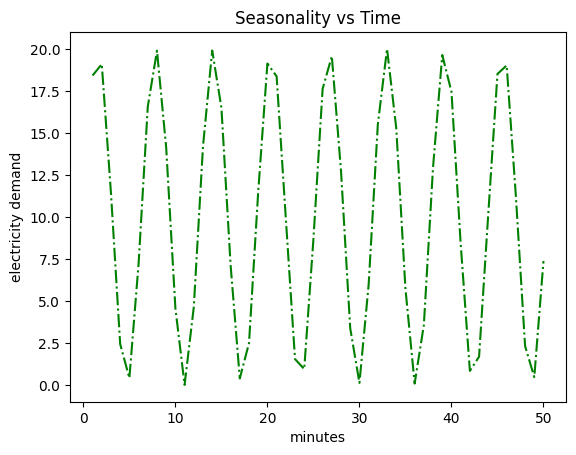

In [6]:
plt.plot(time, seasonal, 'g-.')
plt.title("Seasonality vs Time")
plt.xlabel("minutes")
plt.ylabel("electricity demand")


In [7]:
np.random.seed(10)
residual = np.random.normal(loc=0.0, scale=1, size =len(time))


Text(0, 0.5, 'electricity demand')

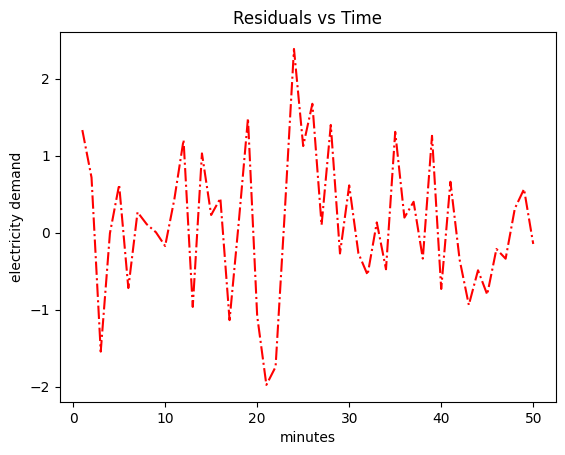

In [8]:
plt.plot(time, residual, 'r-.')
plt.title("Residuals vs Time")
plt.xlabel("minutes")
plt.ylabel("electricity demand")


In [9]:
additive = trend + seasonal + residual

Text(0, 0.5, 'electricity demand')

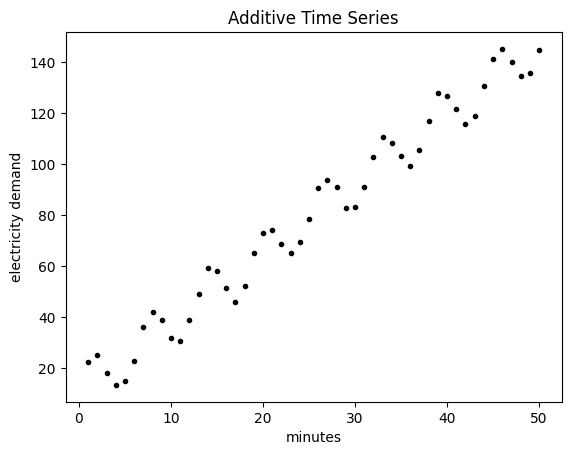

In [10]:
plt.plot(time,additive, 'k.')
plt.title("Additive Time Series")
plt.xlabel("minutes")
plt.ylabel("electricity demand")


In [11]:
ignored_residual = np.ones_like(residual)
multiplicative = trend * seasonal * ignored_residual


Text(0, 0.5, 'electricity demand')

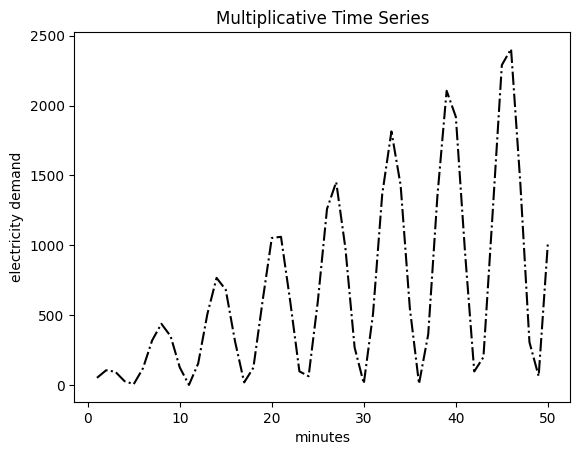

In [12]:
plt.plot(time, multiplicative,'k-.')
plt.title("Multiplicative Time Series")
plt.xlabel("minutes")
plt.ylabel("electricity demand")

In [13]:
# ignored_residual = np.ones_like(residual)
# multiplicative = trend *seasonal*ignored_residual

In [14]:
path_to_file = r"C:\Users\jrdiy\OneDrive\Рабочий стол\vs_code\Time-series\Timer_series_Decomposition\\"

time = np.arange(0,50)
dataset_A = np.load(path_to_file + "dataset_A.npy")
dataset_B = np.load(path_to_file + "dataset_B.npy")


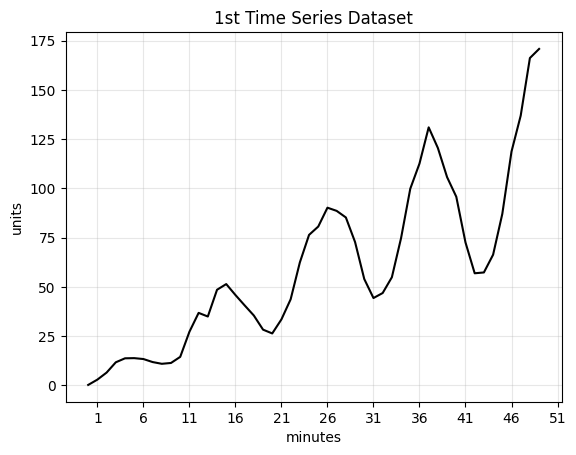

In [15]:
plt.plot(time, dataset_A, 'k-')
plt.title("1st Time Series Dataset")
plt.xlabel("minutes")
plt.ylabel("units")
plt.xticks(np.linspace(1,51,11, dtype='int'))
plt.grid(alpha = 0.3)

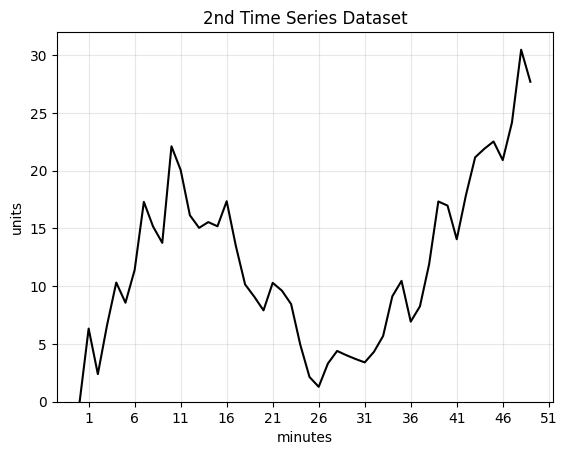

In [16]:
plt.plot(time,dataset_B, 'k-')
plt.title("2nd Time Series Dataset")
plt.xlabel("minutes")
plt.xticks(np.linspace(1,51,11, dtype ='int')) #(51-11)/(11-1)
plt.ylabel("units")
plt.ylim(0,32)
plt.grid(alpha=0.3)


In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

# additive must be defined before this line
ss_decomposition = seasonal_decompose(additive, model='additive', period=6)

estimated_trend = ss_decomposition.trend
estimated_seasonal = ss_decomposition.seasonal
estimated_residual = ss_decomposition.resid


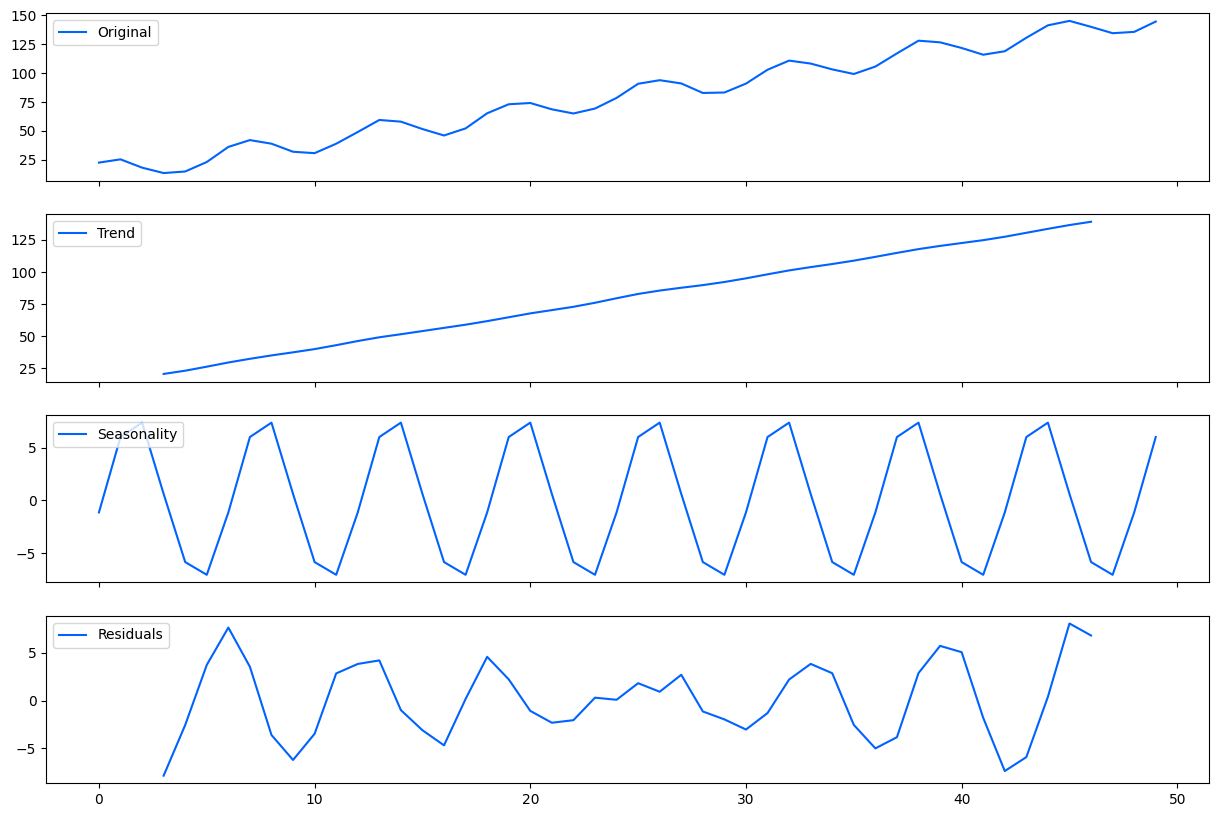

In [18]:
fig, axes = plt.subplots(4, 1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(additive, label='Original')
axes[0].legend(loc='upper left')

axes[1].plot(estimated_trend, label='Trend')
axes[1].legend(loc='upper left')

axes[2].plot(estimated_seasonal, label ='Seasonality')
axes[2].legend(loc='upper left')

axes[3].plot(estimated_residual, label = 'Residuals')
axes[3].legend(loc='upper left')



In [19]:
ss_decomposition = seasonal_decompose(multiplicative, model= 'multiplicative', period =6 )
estimated_trend= ss_decomposition.trend
estimated_sesonal = ss_decomposition.seasonal
estimated_residual = ss_decomposition.resid


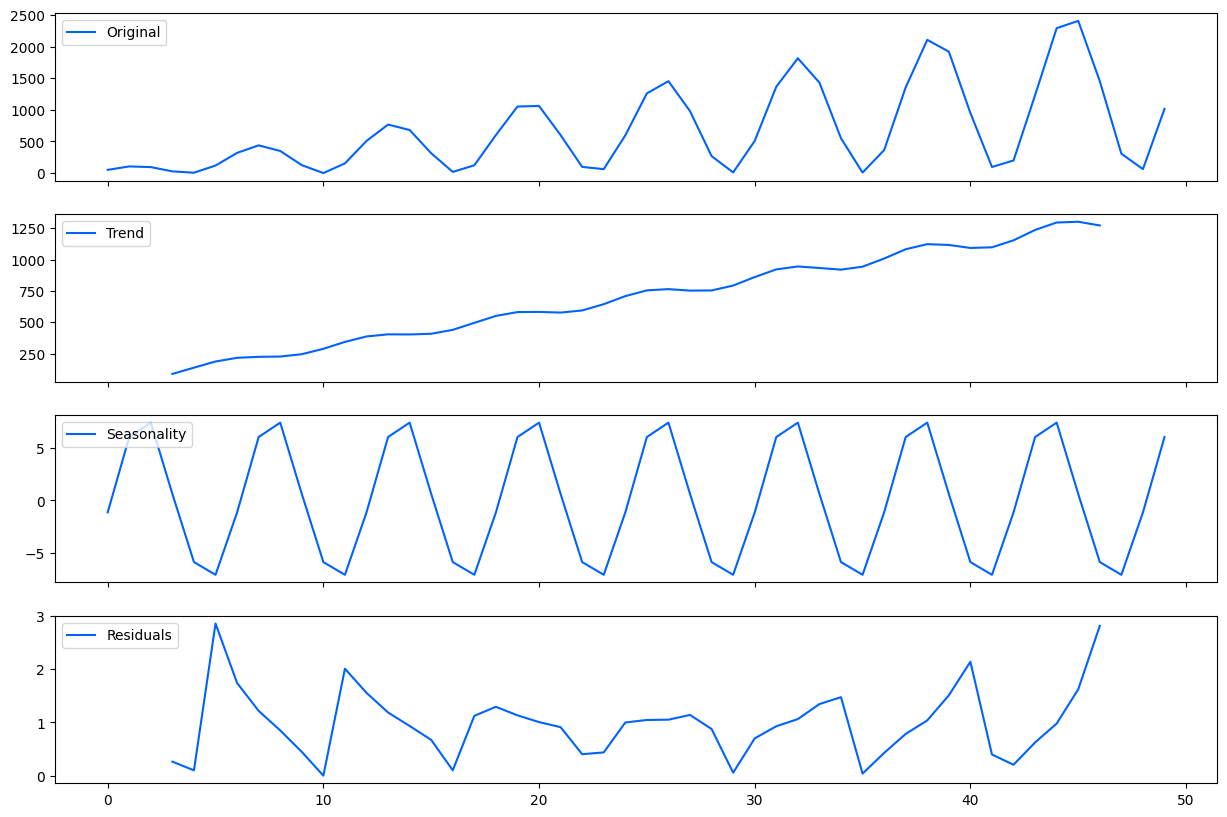

In [20]:
fig, axes =plt.subplots(4,1, sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(multiplicative, label='Original')
axes[0].legend(loc='upper left')

axes[1].plot(estimated_trend, label='Trend')
axes[1].legend(loc='upper left')

axes[2].plot(estimated_seasonal, label='Seasonality')
axes[2].legend(loc='upper left')

axes[3].plot(estimated_residual, label='Residuals')
axes[3].legend(loc='upper left')


In [21]:
ss_decomposition_multi = seasonal_decompose(x=dataset_A,
                                            model = 'multiplicative',
                                            period = 8)
estimated_trend_multi = ss_decomposition_multi.trend
estimated_seasonal_multi = ss_decomposition_multi.seasonal
estimated_residual_multi = ss_decomposition_multi.resid

ss_decomposition_add = seasonal_decompose(x=dataset_B, 
                                          model = 'additive',
                                          period=3)

estimated_trend_add = ss_decomposition_add.trend
estimated_seasonal_add = ss_decomposition_add.seasonal
estimated_residual_add = ss_decomposition_add.resid


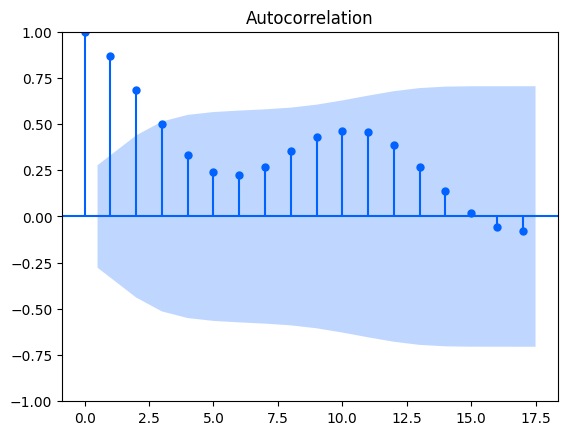

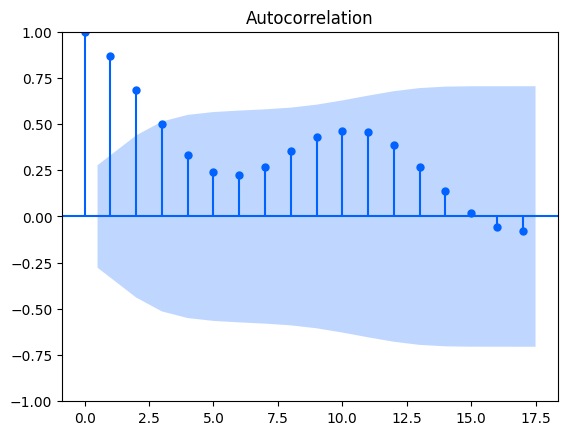

In [22]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(dataset_A)

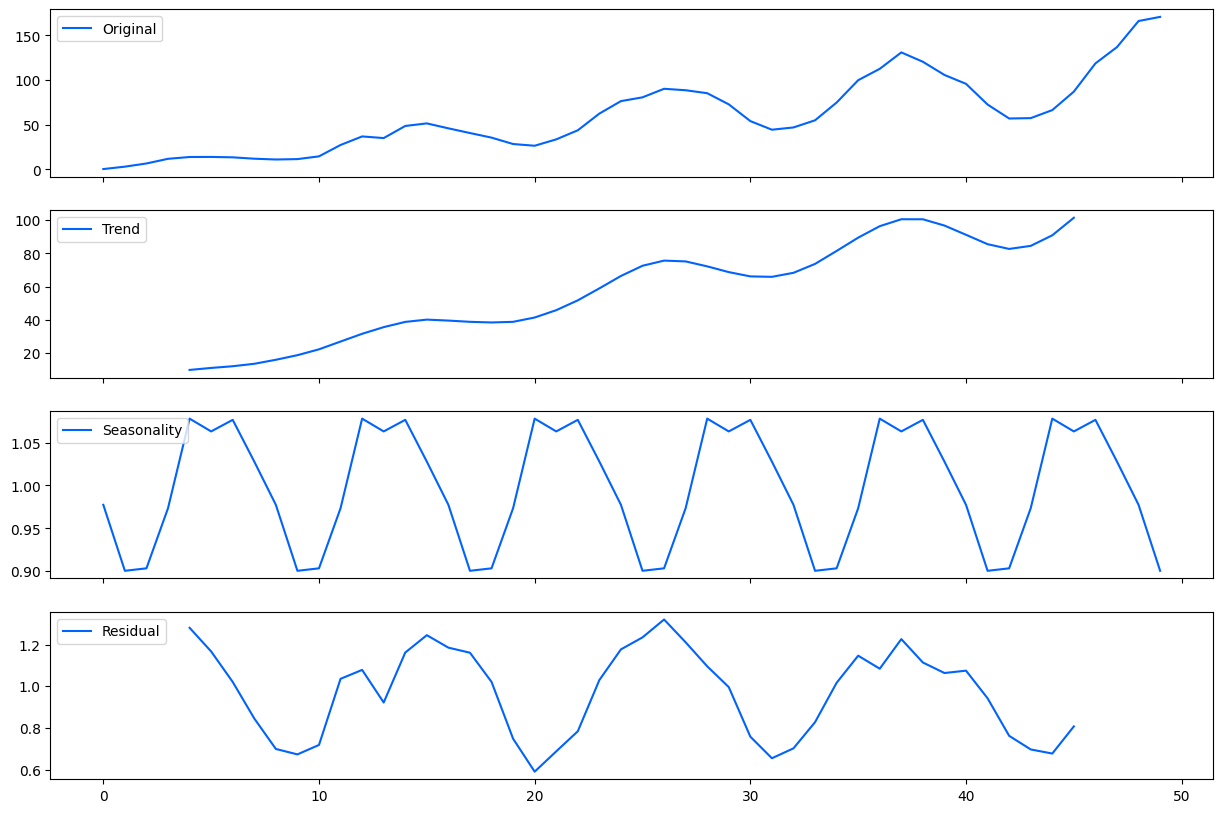

In [23]:
fig, axes = plt.subplots(4,1,sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(dataset_A, label = 'Original')
axes[0].legend(loc='upper left')

axes[1].plot(estimated_trend_multi, label='Trend')
axes[1].legend(loc='upper left')

axes[2].plot(estimated_seasonal_multi, label='Seasonality')
axes[2].legend(loc='upper left')

axes[3].plot(estimated_residual_multi, label='Residual')
axes[3].legend(loc='upper left')



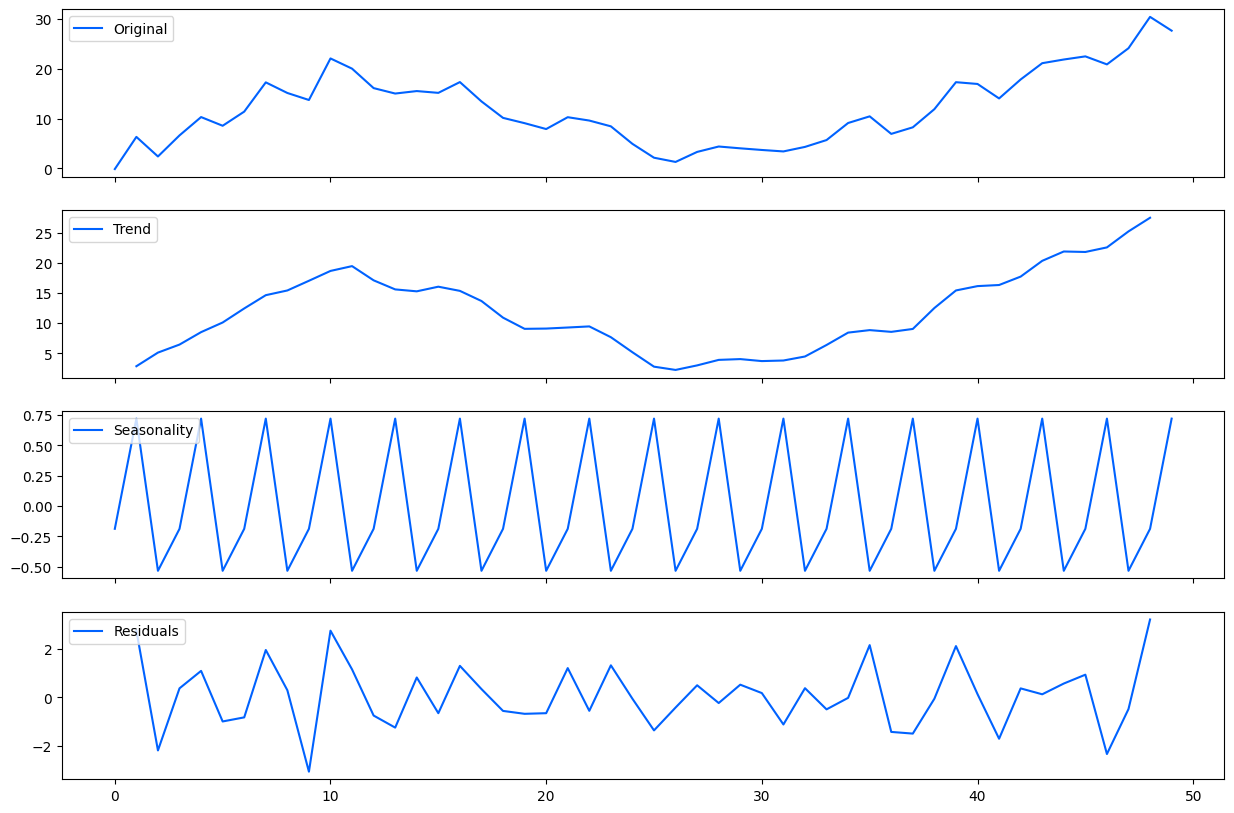

In [24]:
fig,axes = plt.subplots(4,1,sharex=True, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(15)

axes[0].plot(dataset_B, label='Original')
axes[0].legend(loc='upper left')

axes[1].plot(estimated_trend_add, label='Trend')
axes[1].legend(loc='upper left');

axes[2].plot(estimated_seasonal_add, label='Seasonality')
axes[2].legend(loc='upper left');

axes[3].plot(estimated_residual_add, label='Residuals')
axes[3].legend(loc='upper left');